# 01 — EDA, Cleaning & Data Story (Titanic)

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## Task 1 — Load, profile, and save the offline fallback

In [11]:
# The one and only load of the raw dataset for the whole module
df = sns.load_dataset('titanic')

# Committed offline fallback — every later step (including 02_modeling.ipynb) reads THIS file
df.to_csv("titanic.csv", index=False)

print("Shape:", df.shape)
df.head()


Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [13]:
df.describe(include='all')


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_report

,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


**Missing-value percentages measured on the raw 891-row dataset:**

`deck(77.22%)`, `age(19.87%)`, `embarked(0.22%)`, `embark_town(0.22%)` column data is missed.

All other columns (`survived`, `pclass`, `sex`, `sibsp`, `parch`, `fare`, `class`, `who`,
`adult_male`, `alive`, `alone`) have 0% missing.


## Task 2 — Missing-value handling (percentage-threshold rule)

In [15]:
df_clean = df.copy()

# embarked <5% missing -> drop rows (also clears embark_town, same 2 rows)
df_clean = df_clean.dropna(subset=['embarked'])

# age 5-30% missing -> impute with median
age_median = df_clean['age'].median()
df_clean['age'] = df_clean['age'].fillna(age_median)

# deck >30% missing -> drop column (justified above)
df_clean = df_clean.drop(columns=['deck'])

print("Shape after cleaning:", df_clean.shape)
print("\nRemaining missing values:\n", df_clean.isnull().sum().sum(), "total nulls")
df_clean.head()


Shape after cleaning: (889, 14)

Remaining missing values:
 0 total nulls


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


Checking charts folder is created or not to save all ploted charts.

In [ ]:
os.makedirs('charts', exist_ok=True)

## Task 3 — Univariate analysis: `age` and `fare`


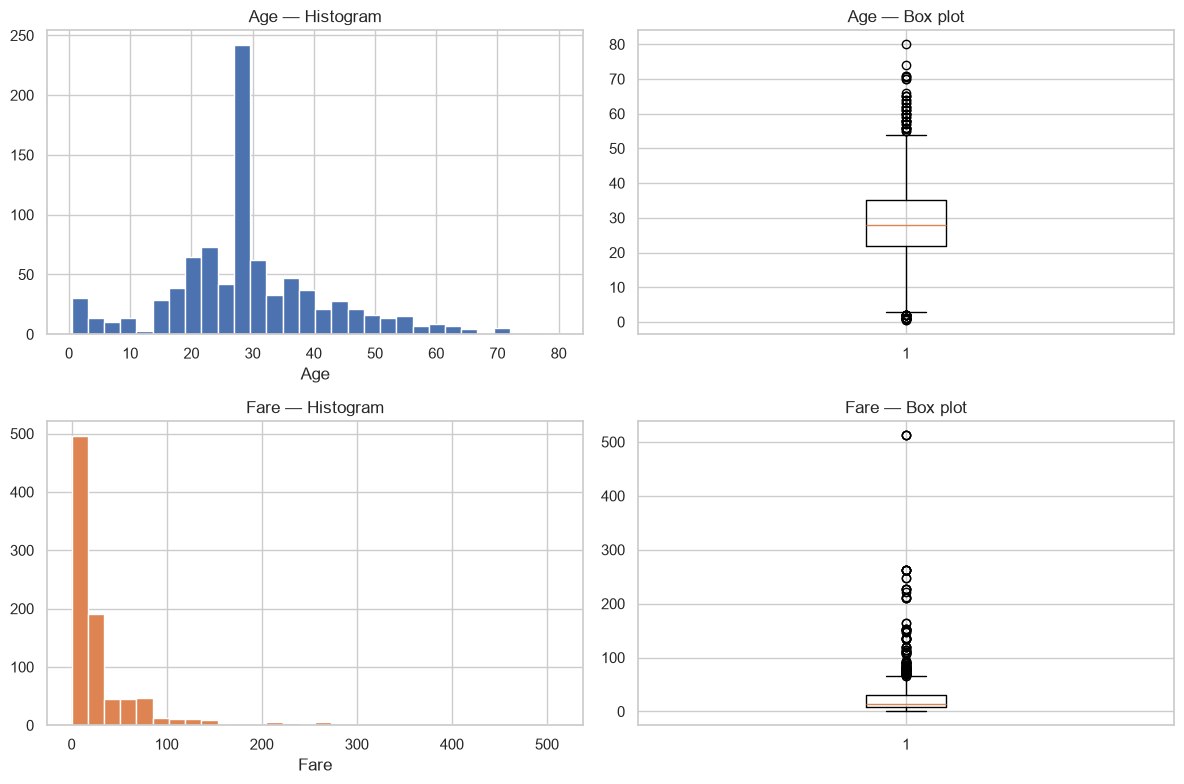

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(df_clean['age'], bins=30, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Age — Histogram')
axes[0,0].set_xlabel('Age')

axes[0,1].boxplot(df_clean['age'], orientation='vertical')
axes[0,1].set_title('Age — Box plot')

axes[1,0].hist(df_clean['fare'], bins=30, color='#DD8452', edgecolor='white')
axes[1,0].set_title('Fare — Histogram')
axes[1,0].set_xlabel('Fare')

axes[1,1].boxplot(df_clean['fare'], orientation='vertical')
axes[1,1].set_title('Fare — Box plot')

plt.tight_layout()
plt.savefig('charts/01_univariate_age_fare.png', dpi=150)
plt.show()


In [18]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = series[(series < lo) | (series > hi)]
    return len(outliers), lo, hi

for col in ['age', 'fare']:
    n_out, lo, hi = iqr_outliers(df_clean[col])
    print(f"{col}: {n_out} IQR outliers  (bounds: [{lo:.2f}, {hi:.2f}])")


age: 65 IQR outliers  (bounds: [2.50, 54.50])
fare: 114 IQR outliers  (bounds: [-26.76, 65.66])


In [19]:
fare_mean = df_clean['fare'].mean()
fare_median = df_clean['fare'].median()
fare_mode = df_clean['fare'].mode()[0]
print(f"fare mean={fare_mean:.2f}, median={fare_median:.2f}, mode={fare_mode:.2f}")


fare mean=32.10, median=14.45, mode=8.05


## Task 4 — Bivariate analysis (boolean masking) and correlation heatmap


In [20]:
# (a) Survival rate by sex — boolean masking
male_mask = (df_clean['sex'] == 'male')
female_mask = (df_clean['sex'] == 'female')

survival_by_sex = pd.Series({
    'female': df_clean.loc[female_mask, 'survived'].mean(),
    'male': df_clean.loc[male_mask, 'survived'].mean(),
})
print("Survival rate by sex:")
print(survival_by_sex.round(3))


Survival rate by sex:
female    0.740
male      0.189
dtype: float64


In [21]:
# (b) Survival rate by pclass — boolean masking
survival_by_pclass = pd.Series({
    p: df_clean.loc[df_clean['pclass'] == p, 'survived'].mean()
    for p in sorted(df_clean['pclass'].unique())
})
print("Survival rate by pclass:")
print(survival_by_pclass.round(3))


Survival rate by pclass:
1    0.626
2    0.473
3    0.242
dtype: float64


In [22]:
# (c) Survival rate by sex AND pclass together — boolean masking with & / |
results = {}
for p in sorted(df_clean['pclass'].unique()):
    for s, s_mask in [('female', female_mask), ('male', male_mask)]:
        mask = s_mask & (df_clean['pclass'] == p)
        results[f"{s}, class {p}"] = df_clean.loc[mask, 'survived'].mean()

survival_by_sex_pclass = pd.Series(results)
print("Survival rate by sex & pclass:")
print(survival_by_sex_pclass.round(3))


Survival rate by sex & pclass:
female, class 1    0.967
male, class 1      0.369
female, class 2    0.921
male, class 2      0.157
female, class 3    0.500
male, class 3      0.135
dtype: float64


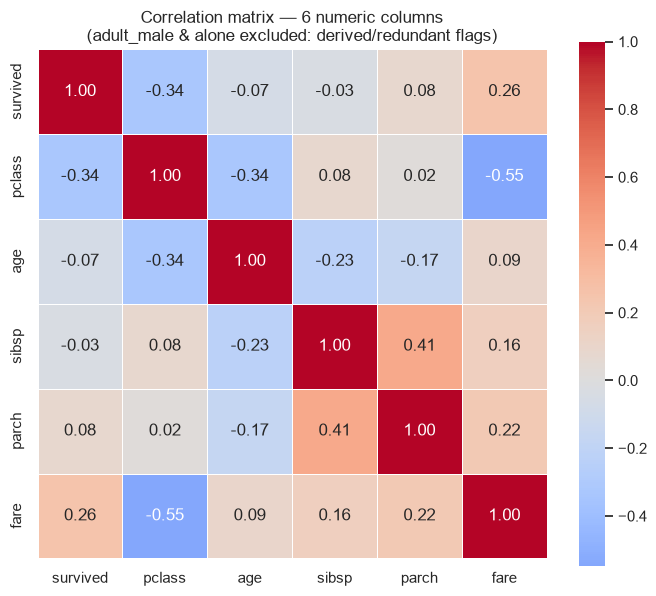

In [23]:
corr_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation matrix — 6 numeric columns\n(adult_male & alone excluded: derived/redundant flags)')
plt.tight_layout()
plt.savefig('charts/02_correlation_heatmap.png', dpi=150)
plt.show()


In [24]:
# Rank all off-diagonal pairs by |correlation| to find the two strongest
pairs = []
for i, c1 in enumerate(corr_cols):
    for j, c2 in enumerate(corr_cols):
        if i < j:
            pairs.append((c1, c2, corr_matrix.loc[c1, c2]))

pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
for c1, c2, v in pairs_sorted[:5]:
    print(f"{c1} <-> {c2}: {v:.3f}")


pclass <-> fare: -0.548
sibsp <-> parch: 0.415
pclass <-> age: -0.337
survived <-> pclass: -0.336
survived <-> fare: 0.255


## Task 5 — Multivariate data story (4+ charts)

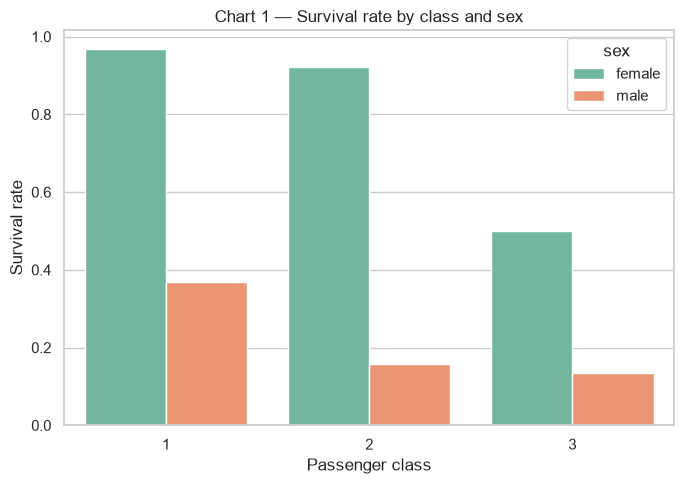

In [25]:
# Chart 1 — survival rate by sex & pclass (bar)
plt.figure(figsize=(7,5))
sns.barplot(data=df_clean, x='pclass', y='survived', hue='sex',
            errorbar=None, palette='Set2')
plt.title('Chart 1 — Survival rate by class and sex')
plt.ylabel('Survival rate')
plt.xlabel('Passenger class')
plt.tight_layout()
plt.savefig('charts/03_survival_by_class_sex.png', dpi=150)
plt.show()


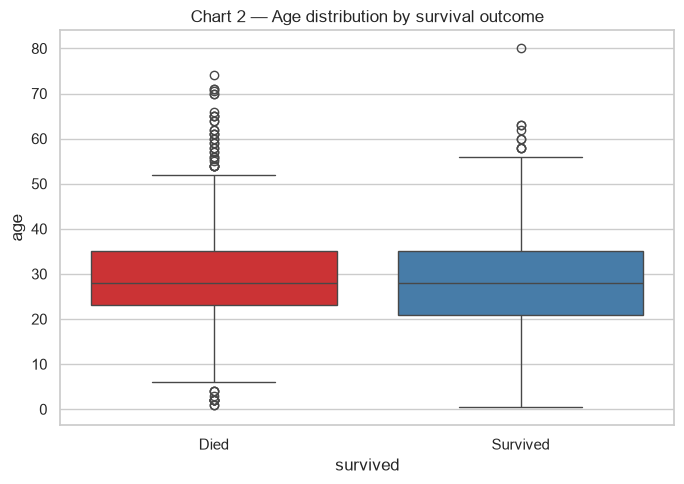

In [26]:
# Chart 2 — age distribution by survival outcome (box)
plt.figure(figsize=(7,5))
sns.boxplot(data=df_clean, x='survived', y='age', hue='survived',
            palette='Set1', legend=False)
plt.xticks([0,1], ['Died', 'Survived'])
plt.title('Chart 2 — Age distribution by survival outcome')
plt.tight_layout()
plt.savefig('charts/04_age_by_survival.png', dpi=150)
plt.show()


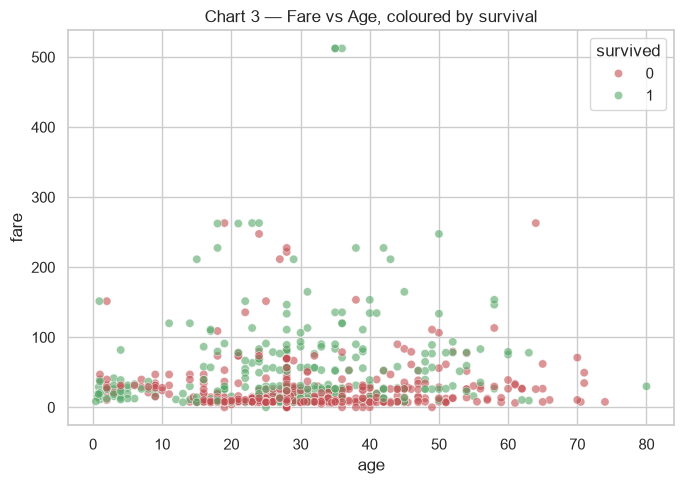

In [27]:
# Chart 3 — fare vs age scatter, coloured by survival
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_clean, x='age', y='fare', hue='survived',
                 palette={0:'#C44E52', 1:'#55A868'}, alpha=0.6)
plt.title('Chart 3 — Fare vs Age, coloured by survival')
plt.tight_layout()
plt.savefig('charts/05_fare_age_scatter.png', dpi=150)
plt.show()


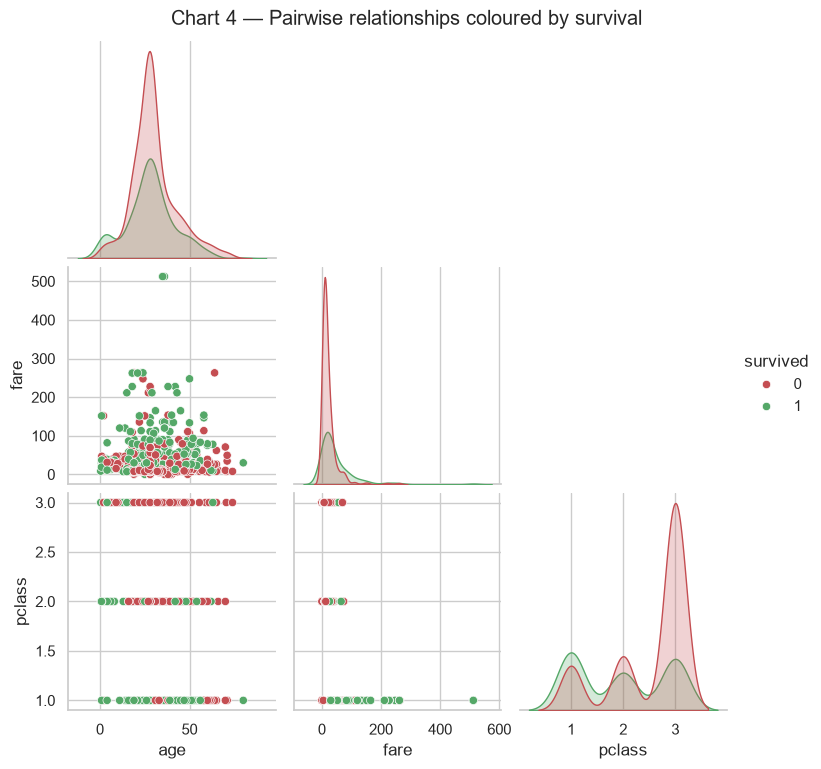

In [28]:
# Chart 4 — pair plot of key numeric features by survival
pairplot_cols = ['survived', 'age', 'fare', 'pclass']
g = sns.pairplot(df_clean[pairplot_cols], hue='survived',
                  palette={0:'#C44E52', 1:'#55A868'}, corner=True, diag_kind='kde')
g.fig.suptitle('Chart 4 — Pairwise relationships coloured by survival', y=1.02)
g.savefig('charts/06_pairplot.png', dpi=150)
plt.show()


## Task 6 — Exploratory standardization sanity check (age, fare)

In [29]:
from sklearn.preprocessing import StandardScaler

check_df = df_clean[['age', 'fare']].copy()
scaler_check = StandardScaler()
scaled_values = scaler_check.fit_transform(check_df)
scaled_df = pd.DataFrame(scaled_values, columns=['age_z', 'fare_z'], index=check_df.index)

summary = pd.DataFrame({
    'age_before_mean': [check_df['age'].mean()],
    'age_before_std': [check_df['age'].std()],
    'age_after_mean': [scaled_df['age_z'].mean()],
    'age_after_std': [scaled_df['age_z'].std()],
    'fare_before_mean': [check_df['fare'].mean()],
    'fare_before_std': [check_df['fare'].std()],
    'fare_after_mean': [scaled_df['fare_z'].mean()],
    'fare_after_std': [scaled_df['fare_z'].std()],
}).round(4)
summary.T


,0
age_before_mean,29.3152
age_before_std,12.9849
age_after_mean,0.0000
age_after_std,1.0006
fare_before_mean,32.0967
fare_before_std,49.6975
fare_after_mean,0.0000
fare_after_std,1.0006


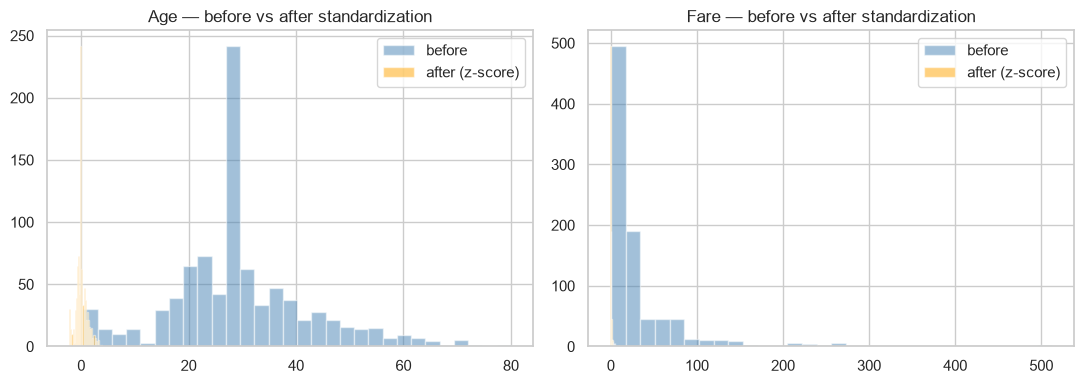

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(check_df['age'], bins=30, alpha=0.5, label='before', color='steelblue')
axes[0].hist(scaled_df['age_z'], bins=30, alpha=0.5, label='after (z-score)', color='orange')
axes[0].set_title('Age — before vs after standardization')
axes[0].legend()

axes[1].hist(check_df['fare'], bins=30, alpha=0.5, label='before', color='steelblue')
axes[1].hist(scaled_df['fare_z'], bins=30, alpha=0.5, label='after (z-score)', color='orange')
axes[1].set_title('Fare — before vs after standardization')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/07_standardization_check.png', dpi=150)
plt.show()
